In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries Imported Successfully!


In [3]:
df = pd.read_csv("../data/Indian_crop_production_yield_dataset.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [4]:
df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167


In [5]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 575879
Columns: 8


In [6]:
df.columns

Index(['State_Name', 'District_Name', 'Crop_Year', 'Season', 'Crop', 'Area',
       'Production', 'yield'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 575879 entries, 0 to 575878
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     575879 non-null  str    
 1   District_Name  575879 non-null  str    
 2   Crop_Year      575879 non-null  int64  
 3   Season         575879 non-null  str    
 4   Crop           575879 non-null  str    
 5   Area           575879 non-null  float64
 6   Production     575879 non-null  float64
 7   yield          575879 non-null  float64
dtypes: float64(3), int64(1), str(4)
memory usage: 35.1 MB


In [8]:
df.describe()

,Crop_Year,Area,Production,yield
count,575879.000000,5.758790e+05,5.758790e+05,5.758790e+05
mean,2007.559402,1.186614e+04,5.689498e+07,4.779376e+03
std,6.174890,4.407750e+04,1.656008e+09,7.109329e+04
min,1997.000000,8.000000e-03,0.000000e+00,0.000000e+00
25%,2002.000000,8.200000e+01,7.270000e+02,1.346025e+00
50%,2007.000000,5.870000e+02,1.220000e+04,4.484848e+01
75%,2013.000000,4.388000e+03,1.859000e+05,1.314807e+02
max,2020.000000,8.580100e+06,1.597800e+11,4.395833e+06


In [9]:
df.describe(include='object')

C:\Users\gfxsc\AppData\Local\Temp\ipykernel_34956\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,State_Name,District_Name,Season,Crop
count,575879,575879,575879,575879
unique,36,730,6,128
top,Uttar Pradesh,BIJAPUR,Kharif,Rice
freq,77804,2069,228520,36040


In [10]:
# Check missing values
missing_values = df.isnull().sum()

print(missing_values)

State_Name       0
District_Name    0
Crop_Year        0
Season           0
Crop             0
Area             0
Production       0
yield            0
dtype: int64


In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

State_Name       0.0
District_Name    0.0
Crop_Year        0.0
Season           0.0
Crop             0.0
Area             0.0
Production       0.0
yield            0.0
dtype: float64

In [12]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [13]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

State_Name: 36
District_Name: 730
Crop_Year: 24
Season: 6
Crop: 128
Area: 48379
Production: 113261
yield: 337362


In [14]:
print("Area = 0 :", (df['Area'] == 0).sum())
print("Production = 0 :", (df['Production'] == 0).sum())
print("Yield = 0 :", (df['yield'] == 0).sum())

Area = 0 : 0
Production = 0 : 3634
Yield = 0 : 3634


In [15]:
print("Negative Area:", (df['Area'] < 0).sum())
print("Negative Production:", (df['Production'] < 0).sum())
print("Negative Yield:", (df['yield'] < 0).sum())

Negative Area: 0
Negative Production: 0
Negative Yield: 0


In [16]:
zero_production = df[df["Production"] == 0]

zero_production.head(10)

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield
395,Andhra Pradesh,ANANTAPUR,2002,Kharif,Soyabean,51.0,0.0,0.0
422,Andhra Pradesh,ANANTAPUR,2002,Whole Year,Cucumber,18.0,0.0,0.0
426,Andhra Pradesh,ANANTAPUR,2002,Whole Year,other fibres,132.0,0.0,0.0
428,Andhra Pradesh,ANANTAPUR,2002,Whole Year,Other Vegetables,1767.0,0.0,0.0
479,Andhra Pradesh,ANANTAPUR,2003,Whole Year,Cucumber,51.0,0.0,0.0
484,Andhra Pradesh,ANANTAPUR,2003,Whole Year,Other Vegetables,1783.0,0.0,0.0
1196,Andhra Pradesh,CHITTOOR,2002,Whole Year,Cabbage,4.0,0.0,0.0
1201,Andhra Pradesh,CHITTOOR,2002,Whole Year,Cucumber,8.0,0.0,0.0
1206,Andhra Pradesh,CHITTOOR,2002,Whole Year,Other Vegetables,918.0,0.0,0.0
1208,Andhra Pradesh,CHITTOOR,2002,Whole Year,Peas (vegetable),1.0,0.0,0.0


In [17]:
zero_production.describe(include="all")

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield
count,3634,3634,3634.000000,3634,3634,3634.000000,3634.0,3634.0
unique,21,298,NaN,4,88,NaN,NaN,NaN
top,Madhya Pradesh,DINDIGUL,NaN,Whole Year,Other Vegetables,NaN,NaN,NaN
freq,1087,48,NaN,2749,286,NaN,NaN,NaN
mean,NaN,NaN,2002.459824,NaN,NaN,316.673913,0.0,0.0
std,NaN,NaN,2.158630,NaN,NaN,2554.300040,0.0,0.0
min,NaN,NaN,1999.000000,NaN,NaN,1.000000,0.0,0.0
25%,NaN,NaN,2002.000000,NaN,NaN,8.000000,0.0,0.0
50%,NaN,NaN,2002.000000,NaN,NaN,41.000000,0.0,0.0
75%,NaN,NaN,2003.000000,NaN,NaN,148.000000,0.0,0.0


In [18]:
## Outlier Detection

C:\Users\gfxsc\AppData\Local\Temp\ipykernel_34956\2191881356.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


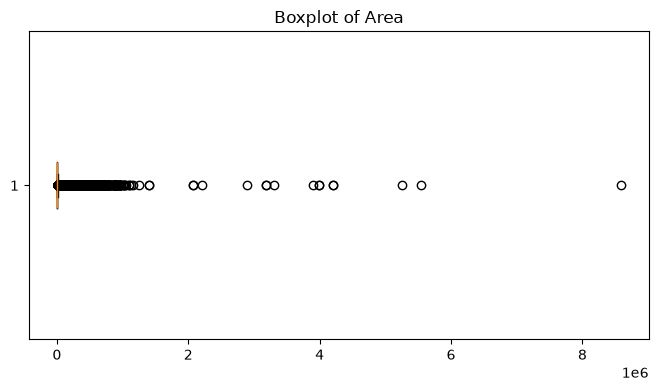

C:\Users\gfxsc\AppData\Local\Temp\ipykernel_34956\2191881356.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


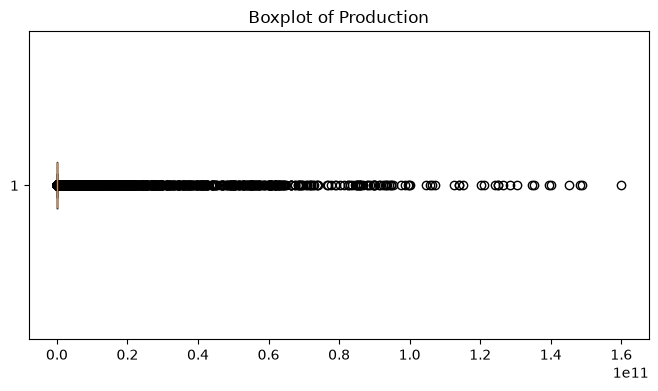

C:\Users\gfxsc\AppData\Local\Temp\ipykernel_34956\2191881356.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False)


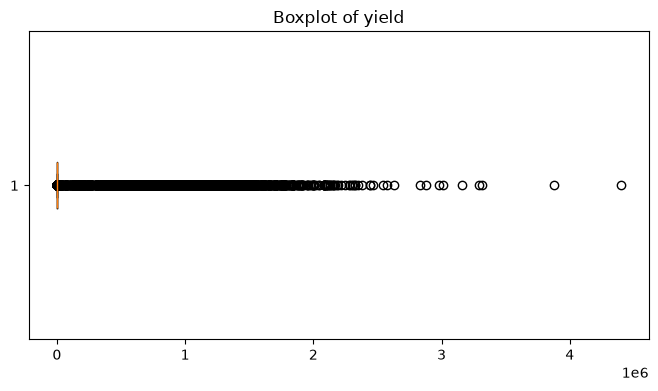

In [19]:
import matplotlib.pyplot as plt

numerical_cols = ["Area", "Production", "yield"]

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [20]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower) | (data[column] > upper)]

    print(f"{column}")
    print(f"Lower Bound : {lower}")
    print(f"Upper Bound : {upper}")
    print(f"Number of Outliers : {len(outliers)}")
    print("-"*50)

In [21]:
for col in ["Area", "Production", "yield"]:
    detect_outliers(df, col)

Area
Lower Bound : -6377.0
Upper Bound : 10847.0
Number of Outliers : 95301
--------------------------------------------------
Production
Lower Bound : -277032.5
Upper Bound : 463659.5
Number of Outliers : 103661
--------------------------------------------------
yield
Lower Bound : -193.85595415043613
Upper Bound : 326.6826557351052
Number of Outliers : 69067
--------------------------------------------------


In [22]:
## Exploratory Data Analysis (EDA)

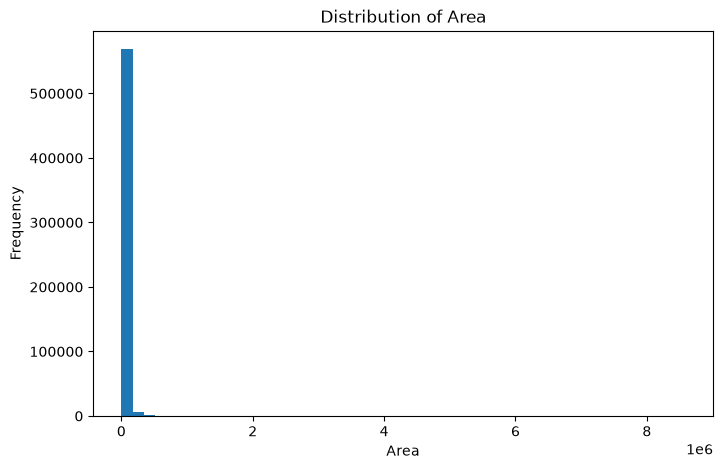

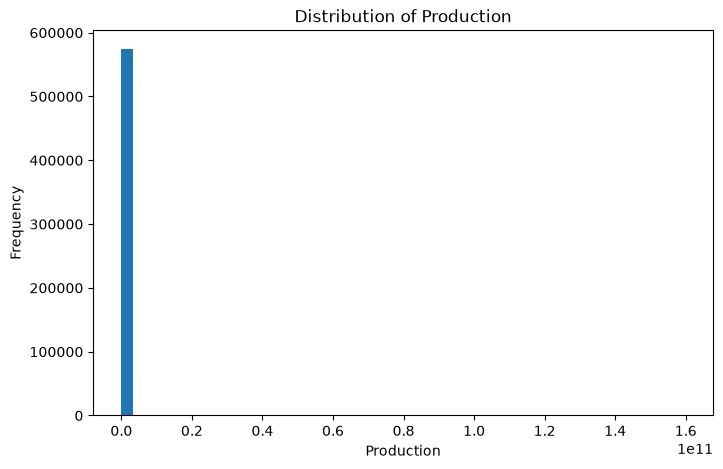

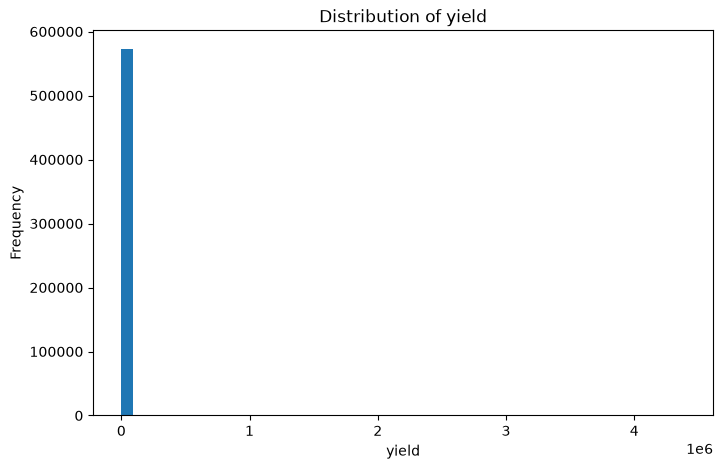

In [23]:
import matplotlib.pyplot as plt

numerical_columns = ["Area", "Production", "yield"]

for col in numerical_columns:
    plt.figure(figsize=(8,5))
    plt.hist(df[col], bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [24]:
import numpy as np

df["Log_Area"] = np.log1p(df["Area"])
df["Log_Production"] = np.log1p(df["Production"])
df["Log_Yield"] = np.log1p(df["yield"])

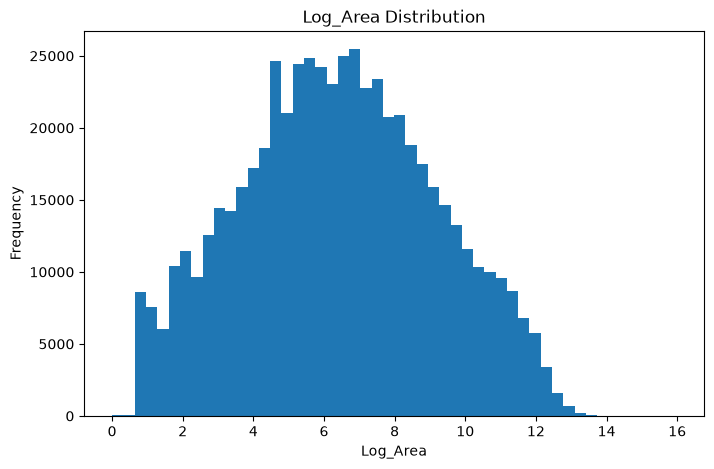

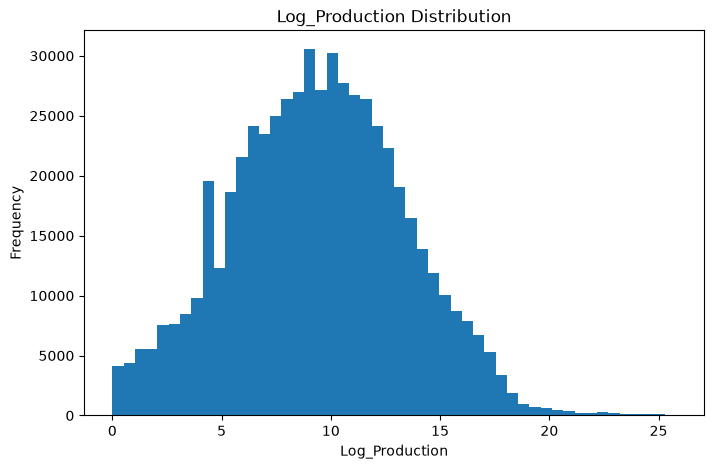

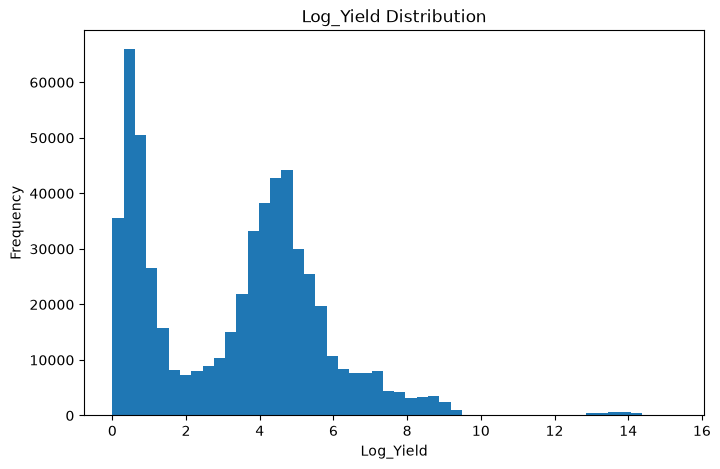

In [25]:
log_columns = ["Log_Area", "Log_Production", "Log_Yield"]

for col in log_columns:
    plt.figure(figsize=(8,5))
    plt.hist(df[col], bins=50)
    plt.title(f"{col} Distribution")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [26]:
df.to_csv(
    "../cleaned_data/Indian_crop_production_yield_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [27]:
# Exploratory Data Analysis

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

In [29]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 575879
Columns: 11


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,yield,Log_Area,Log_Production,Log_Yield
0,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0,1.594896,7.134891,7.601402,0.953547
1,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0,0.500000,1.098612,0.693147,0.405465
2,Andaman and Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0,3.147059,4.634729,5.774552,1.422399
3,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Banana,176.0,641.0,3.642045,5.176150,6.464588,1.535155
4,Andaman and Nicobar Islands,NICOBARS,2000,Whole Year,Cashewnut,720.0,165.0,0.229167,6.580639,5.111988,0.206336


In [30]:
print("Total States:", df["State_Name"].nunique())

print(df["State_Name"].unique())

Total States: 36
<StringArray>
['Andaman and Nicobar Islands',              'Andhra Pradesh',
           'Arunachal Pradesh',                       'Assam',
                       'Bihar',                  'Chandigarh',
                'Chhattisgarh',      'Dadra and Nagar Haveli',
                         'Goa',                     'Gujarat',
                     'Haryana',            'Himachal Pradesh',
           'Jammu and Kashmir',                   'Jharkhand',
                   'Karnataka',                      'Kerala',
              'Madhya Pradesh',                 'Maharashtra',
                     'Manipur',                   'Meghalaya',
                     'Mizoram',                    'Nagaland',
                      'Odisha',                  'Puducherry',
                      'Punjab',                   'Rajasthan',
                      'Sikkim',                  'Tamil Nadu',
                   'Telangana',                     'Tripura',
               'Uttar Pr

In [31]:
print("Total Crops:", df["Crop"].nunique())

Total Crops: 128


In [32]:
print(df["Season"].value_counts())

Season
Kharif        228520
Rabi          163676
Whole Year    122153
Summer         36071
Winter         13987
Autumn         11472
Name: count, dtype: int64


In [33]:
print("Districts:", df["District_Name"].nunique())

Districts: 730


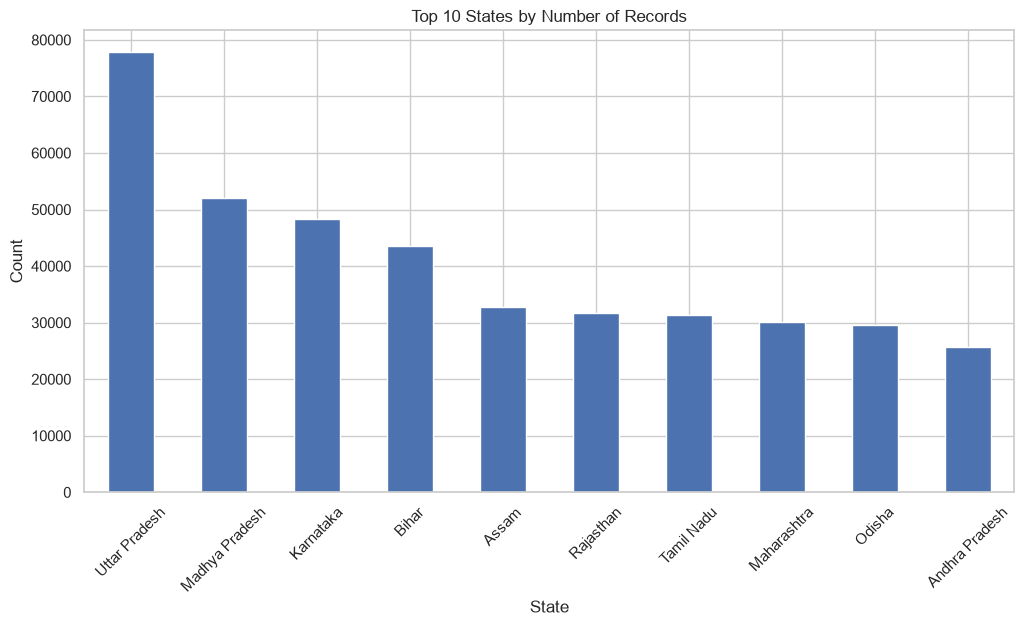

In [34]:
plt.figure(figsize=(12,6))

df["State_Name"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 States by Number of Records")
plt.xlabel("State")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

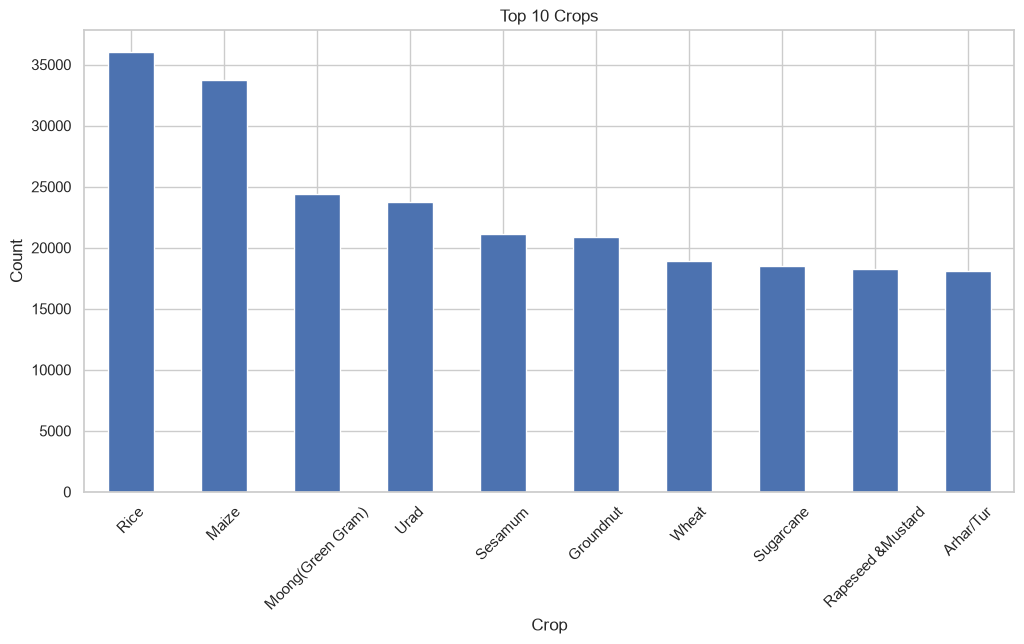

In [35]:
plt.figure(figsize=(12,6))

df["Crop"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Crops")
plt.xlabel("Crop")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

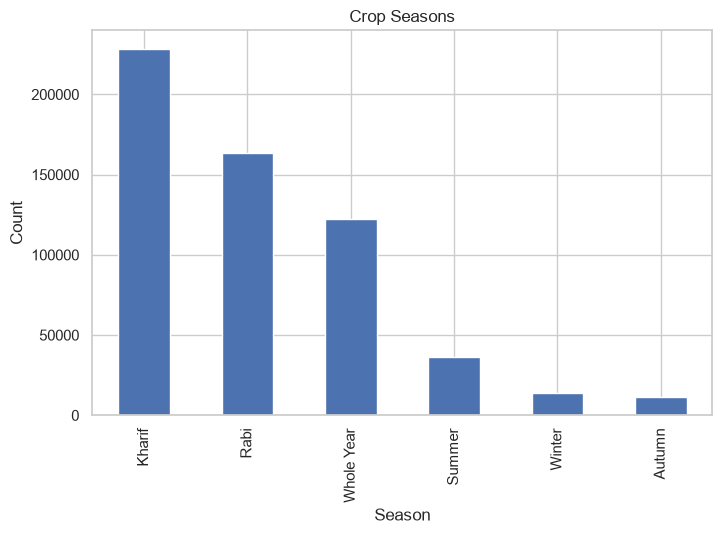

In [36]:
plt.figure(figsize=(8,5))

df["Season"].value_counts().plot(kind="bar")

plt.title("Crop Seasons")
plt.xlabel("Season")
plt.ylabel("Count")

plt.show()

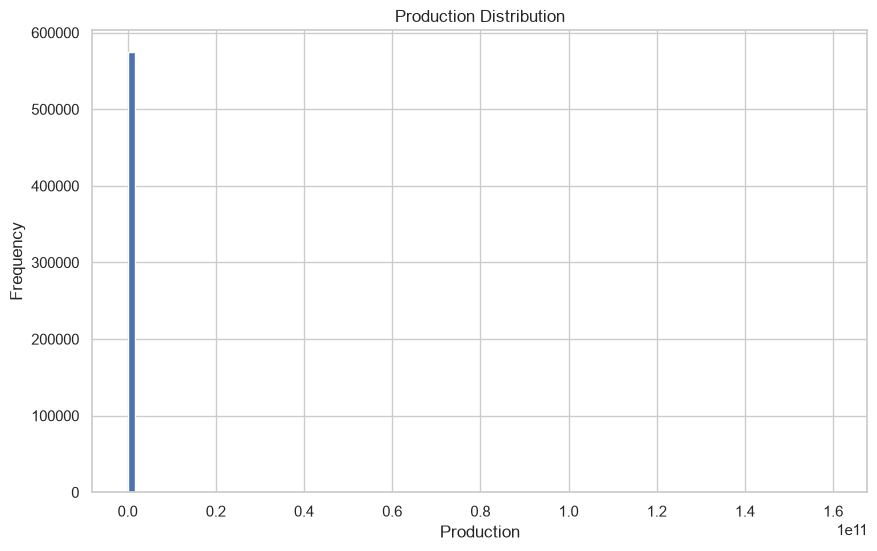

In [37]:
plt.figure(figsize=(10,6))

plt.hist(df["Production"], bins=100)

plt.title("Production Distribution")

plt.xlabel("Production")

plt.ylabel("Frequency")

plt.show()

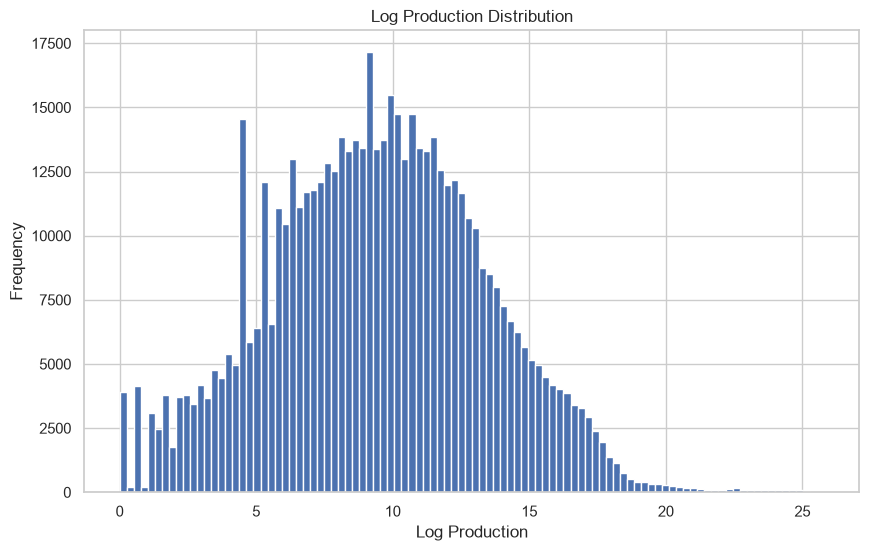

In [38]:
plt.figure(figsize=(10,6))

plt.hist(df["Log_Production"], bins=100)

plt.title("Log Production Distribution")

plt.xlabel("Log Production")

plt.ylabel("Frequency")

plt.show()

In [39]:
corr = df[["Area","Production","yield"]].corr()

corr

,Area,Production,yield
Area,1.000000,0.039189,0.000058
Production,0.039189,1.000000,0.438115
yield,0.000058,0.438115,1.000000


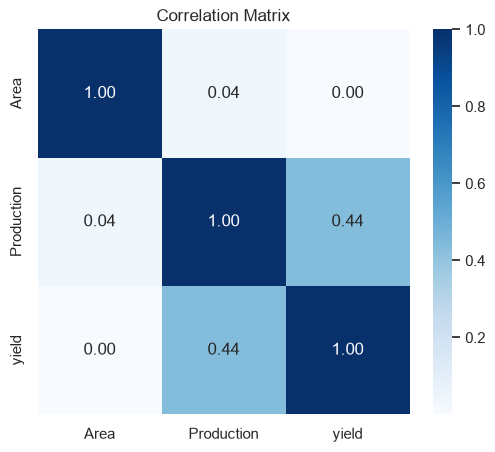

In [40]:
plt.figure(figsize=(6,5))

sns.heatmap(corr,
            annot=True,
            cmap="Blues",
            fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

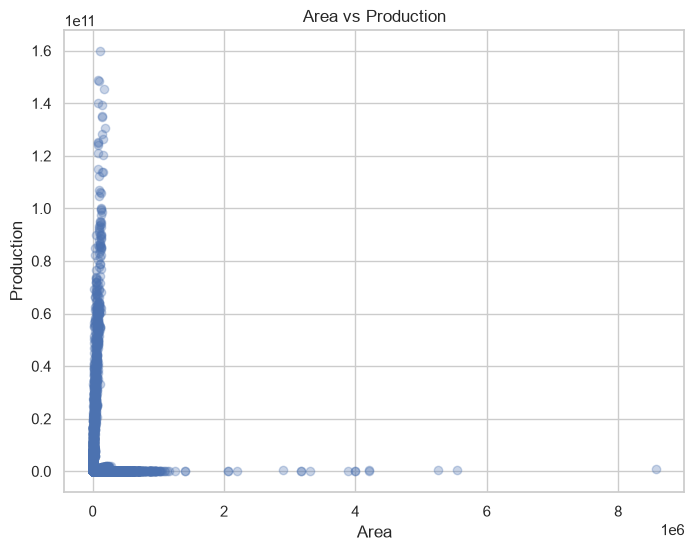

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Area"],
    df["Production"],
    alpha=0.3
)

plt.xlabel("Area")

plt.ylabel("Production")

plt.title("Area vs Production")

plt.show()

In [42]:
clean_df = df.copy()

In [43]:
text_columns = ["State_Name", "District_Name", "Season", "Crop"]

for col in text_columns:
    clean_df[col] = clean_df[col].str.strip()

In [44]:
for col in text_columns:
    print(col, clean_df[col].str.contains(r"^\s|\s$", regex=True).sum())

State_Name 0
District_Name 0
Season 0
Crop 0


In [45]:
clean_df.to_csv(
    "../cleaned_data/Indian_crop_production_yield_cleaned.csv",
    index=False
)

print("Dataset saved successfully!")

Dataset saved successfully!
